# Financial News Sentiment as a Short-Term Equity Signal

Author: Luu Nguyen Hanh Duyen  
Project: Equity Sentiment Alpha Study

This notebook investigates whether financial news sentiment predicts short-term stock returns.
We construct a cross-sectional sentiment signal and evaluate its predictive power using quintile portfolios and long–short strategies.

## 1. Research Question

Does financial news sentiment predict short-term stock returns?

### Economic intuition

Financial news introduces new information into the market.  
However, investors may not immediately incorporate this information into prices.

This delayed reaction may create predictable short-term return patterns.

We test whether stocks associated with more positive news sentiment outperform those with negative sentiment over the next close-to-close trading-day horizon.

### Canonical timing and return definitions

- **Signal cutoff:** 16:00:00 America/New_York, exclusive. News before 16:00 enters that trading day's close signal; news at or after 16:00 enters the next trading day's signal.
- **Signal date (`date_t`):** the trading close at which the portfolio is formed.
- **Return horizon:** close on `date_t` to the next available trading close.
- **Daily long-short return:** equal-weighted Q5 return minus equal-weighted Q1 return, with 200% gross and 0% net exposure before costs.
- **Cumulative return:** compounded daily long-short returns. Arithmetic cumulative spread is a diagnostic, not portfolio wealth.

## 2. Dataset Overview

Universe: securities present in the point-in-time US daily price tape; today's company master is optional metadata and never an eligibility filter.
News source: Financial news API  
Data frequency: Daily aggregation

Key datasets:

- News articles with sentiment scores
- Daily stock prices and returns
- Liquidity metrics
- Sentiment signals aggregated at the stock-day level
- Daily US Fama–French market, size, value, momentum, and risk-free factors

The price tape preserves tickers that later disappear from the current company master, reducing survivorship bias. Security-type history is not available, so the point-in-time universe may still contain non-common-stock instruments.

In [1]:
from pathlib import Path
import os
import sys

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

project_root = Path.cwd()
if not (project_root / "equity_sentiment").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.analysis.robustness import (
    factor_alpha,
    grouped_inference,
    hac_mean,
    moving_block_bootstrap_mean,
    two_sample_block_bootstrap_difference,
)

HAC_LAGS = 5
BLOCK_LENGTH = 5
BOOTSTRAP_REPETITIONS = 5000
OOS_START_DATE = pd.Timestamp("2025-12-15")
RANDOM_SEED = 42

configured_db_path = os.getenv("EQUITY_SENTIMENT_DB_PATH")
db_path = (
    Path(configured_db_path)
    if configured_db_path
    else project_root / "equity_sentiment" / "dev.duckdb"
)
con = duckdb.connect(str(db_path), read_only=True)


### Universe statistics

In [2]:
query = """
SELECT
    COUNT(DISTINCT ticker) AS num_stocks,
    COUNT(DISTINCT date_t) AS num_days,
    COUNT(*) AS observations
FROM fct_signal_panel
"""

con.execute(query).df()

,num_stocks,num_days,observations
0,6632,133,107422


### News coverage over time

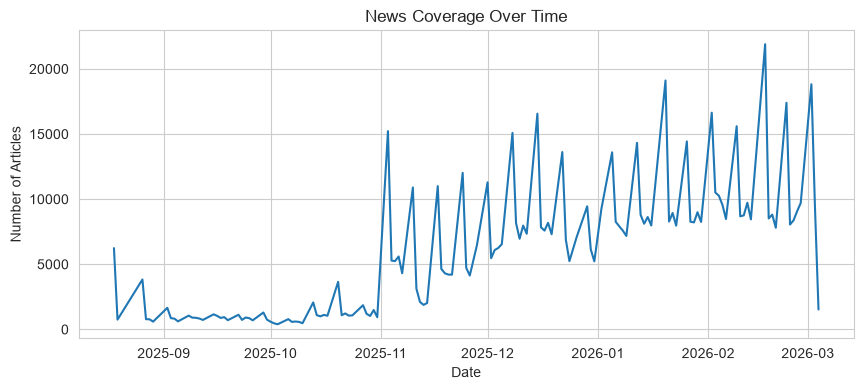

In [3]:
query = """
SELECT
    date_t,
    COUNT(*) AS news_articles
FROM stg_news
GROUP BY 1
ORDER BY 1
"""

news = con.execute(query).df()

plt.figure(figsize=(10,4))
plt.plot(news.date_t, news.news_articles)
plt.title("News Coverage Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

News coverage varies significantly across time due to differences in market activity and API coverage.

## 3. Sentiment Signal Construction

Article-level sentiment scores are aggregated to the stock-day level using a relevance-weighted average.

To reduce noise in the signal, the analysis focuses only on stock-days with meaningful news coverage.

Filtering rules:

• `has_sentiment_flag = 1`  
• `news_count > 1`

This ensures that the sentiment signal is constructed only when multiple articles discuss the same stock on a given day.

Trading signal: `LS_t = R^{close-to-close}_{Q5,t→t+1} - R^{close-to-close}_{Q1,t→t+1}`

Where:
• Q5 = stocks with the most positive sentiment  
• Q1 = stocks with the most negative sentiment

The strategy allocates one unit long to Q5 and one unit short to Q1, then holds from close `t` to close `t+1`. Reported returns therefore represent 200% gross and 0% net exposure before costs.

## 4. Sentiment Quintile Returns

Stocks are ranked daily by sentiment score and assigned into quintiles.

We test whether stocks in higher sentiment quintiles deliver higher next-day returns.

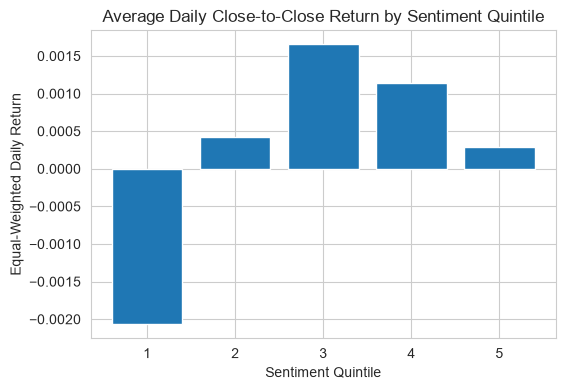

In [4]:
query = """
WITH daily_quintile AS (
    SELECT
        date_t,
        sentiment_quintile,
        AVG(forward_return_close_to_close_1d) AS daily_return_ew
    FROM fct_signal_panel
    WHERE forward_return_close_to_close_1d IS NOT NULL
    GROUP BY 1, 2
)
SELECT
    sentiment_quintile,
    AVG(daily_return_ew) AS avg_daily_return_ew,
    COUNT(*) AS trading_days
FROM daily_quintile
GROUP BY 1
ORDER BY 1
"""

quintile = con.execute(query).df()

plt.figure(figsize=(6,4))
plt.bar(quintile.sentiment_quintile, quintile.avg_daily_return_ew)

plt.title("Average Daily Close-to-Close Return by Sentiment Quintile")
plt.xlabel("Sentiment Quintile")
plt.ylabel("Equal-Weighted Daily Return")

plt.show()

Returns generally increase with sentiment rank, suggesting that stocks associated with more positive sentiment tend to outperform those with negative sentiment.

## 5. Long–Short Portfolio Performance

We construct a daily long–short portfolio:

Long: Q5 (most positive sentiment)  
Short: Q1 (most negative sentiment)

The performance of this strategy is measured using the equal-weighted spread between the two portfolios.

In [5]:
query = """
SELECT
    date_t,
    long_short_return_ew,
    cumulative_return_ew
FROM fct_signal_daily
ORDER BY 1
"""

spread = con.execute(query).df()
spread.head()

,date_t,long_short_return_ew,cumulative_return_ew
0,2025-08-18,-0.001283,-0.001283
1,2025-08-19,0.005857,0.004566
2,2025-08-26,0.004980,0.009569
3,2025-08-27,0.015366,0.025082
4,2025-08-28,-0.013960,0.010772


### Cumulative returns

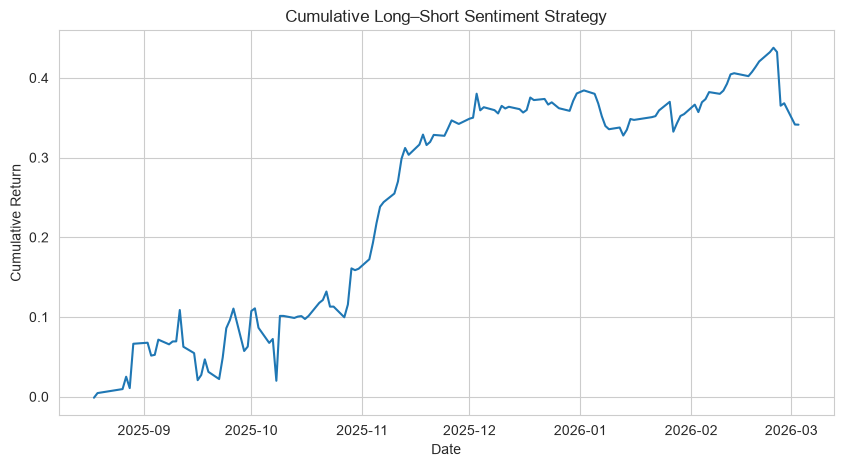

In [6]:
plt.figure(figsize=(10,5))
plt.plot(spread.date_t, spread.cumulative_return_ew)

plt.title("Cumulative Long–Short Sentiment Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.show()

The chart compounds the canonical daily long-short return. It represents a hypothetical 200%-gross portfolio before financing, borrow fees, transaction costs, and slippage.

## 6. Robust Full-Sample Inference and Signal Stability
The headline mean uses Newey–West HAC standard errors with five lags and a five-day circular moving-block bootstrap. The rolling t-statistic below remains descriptive only.

In [7]:
query = """
SELECT
    date_t,
    long_short_mean_20d,
    t_stat_20d
FROM fct_signal_rolling
ORDER BY 1
"""

rolling = con.execute(query).df()

overall_hac = hac_mean(spread.long_short_return_ew, maxlags=HAC_LAGS)
overall_hac.update(moving_block_bootstrap_mean(
    spread.long_short_return_ew,
    block_length=BLOCK_LENGTH,
    repetitions=BOOTSTRAP_REPETITIONS,
    seed=RANDOM_SEED,
))
overall_inference = pd.DataFrame([overall_hac])
overall_inference

,n_days,estimate,hac_se,hac_t,hac_p,hac_ci_low,hac_ci_high,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p
0,132,0.002359,0.001158,2.037443,0.041606,0.00009,0.004628,0.000035,0.004679,0.0468


### Rolling mean spread

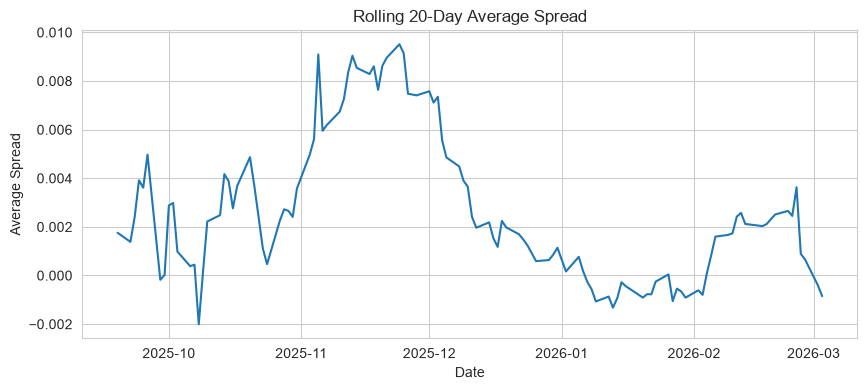

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rolling.date_t, rolling.long_short_mean_20d)

plt.title("Rolling 20-Day Average Spread")
plt.xlabel("Date")
plt.ylabel("Average Spread")

plt.show()

### Rolling t-statistic

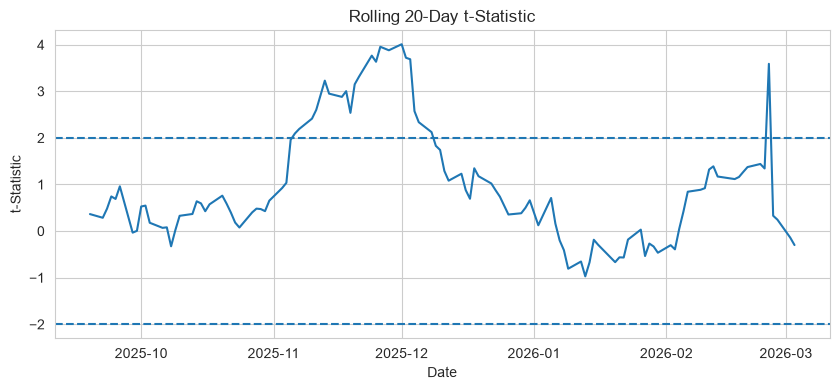

In [9]:
plt.figure(figsize=(10,4))
plt.plot(rolling.date_t, rolling.t_stat_20d)

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.title("Rolling 20-Day t-Statistic")
plt.xlabel("Date")
plt.ylabel("t-Statistic")

plt.show()

The rolling chart is a stability diagnostic. Statistical claims use the full-sample HAC and block-bootstrap intervals reported above, not the rolling IID t-statistic.

## 7. Liquidity Interaction
Information diffusion may vary across stocks with different liquidity levels.

We test whether the sentiment signal is stronger among lower-liquidity stocks.

,n_days,estimate,hac_se,hac_t,hac_p,hac_ci_low,hac_ci_high,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p,liquidity_bucket,hac_p_holm
1,118,0.000160,0.005995,0.026720,0.978683,-0.011589,0.011910,-0.012601,0.010712,0.9372,Low Liquidity,0.978683
0,132,0.002568,0.001223,2.098555,0.035856,0.000170,0.004966,0.000111,0.005188,0.0380,High Liquidity,0.071712
2,122,0.014713,0.005814,2.530865,0.011378,0.003319,0.026108,0.004382,0.026868,0.0040,Mid Liquidity,0.034135


,n_days,estimate,hac_se,hac_t,hac_p,hac_ci_low,hac_ci_high,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p,contrast
0,118,-0.002067,0.005884,-0.351325,0.725344,-0.013601,0.009466,-0.014207,0.008678,0.7792,Low minus High liquidity


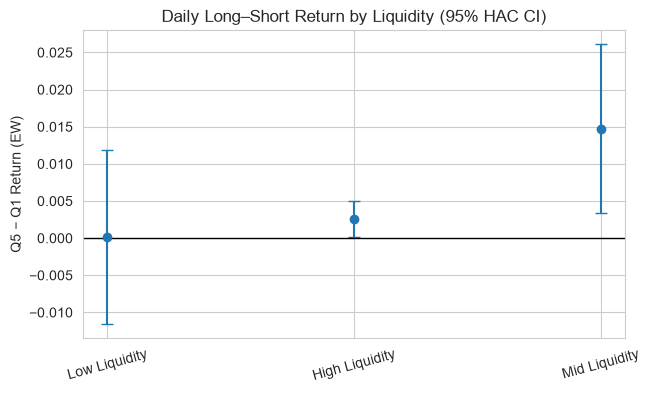

In [10]:
query = """
WITH daily_bucket AS (
    SELECT
        date_t,
        liquidity_bucket,
        AVG(CASE WHEN sentiment_quintile = 5 THEN forward_return_close_to_close_1d END)
        - AVG(CASE WHEN sentiment_quintile = 1 THEN forward_return_close_to_close_1d END)
            AS long_short_return_ew
    FROM fct_signal_panel
    GROUP BY 1, 2
)
SELECT date_t, liquidity_bucket, long_short_return_ew
FROM daily_bucket
WHERE long_short_return_ew IS NOT NULL
ORDER BY date_t, liquidity_bucket
"""

liquidity_daily = con.execute(query).df()
liquidity_inference = grouped_inference(
    liquidity_daily, "liquidity_bucket", "long_short_return_ew",
    maxlags=HAC_LAGS, block_length=BLOCK_LENGTH,
    repetitions=BOOTSTRAP_REPETITIONS, seed=RANDOM_SEED,
)
liquidity_inference = liquidity_inference.sort_values("estimate")

liquidity_pivot = liquidity_daily.pivot(
    index="date_t", columns="liquidity_bucket", values="long_short_return_ew"
).dropna(subset=["Low Liquidity", "High Liquidity"])
liquidity_difference = liquidity_pivot["Low Liquidity"] - liquidity_pivot["High Liquidity"]
liquidity_contrast = hac_mean(liquidity_difference, maxlags=HAC_LAGS)
liquidity_contrast.update(moving_block_bootstrap_mean(
    liquidity_difference, BLOCK_LENGTH, BOOTSTRAP_REPETITIONS, RANDOM_SEED
))
liquidity_contrast["contrast"] = "Low minus High liquidity"

display(liquidity_inference)
display(pd.DataFrame([liquidity_contrast]))

plt.figure(figsize=(7,4))
plt.errorbar(
    liquidity_inference.liquidity_bucket, liquidity_inference.estimate,
    yerr=[
        liquidity_inference.estimate - liquidity_inference.hac_ci_low,
        liquidity_inference.hac_ci_high - liquidity_inference.estimate,
    ], fmt="o", capsize=4,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Daily Long–Short Return by Liquidity (95% HAC CI)")
plt.ylabel("Q5 − Q1 Return (EW)")
plt.xticks(rotation=15)
plt.show()

Each point is the mean of daily within-bucket Q5-minus-Q1 returns. HAC and block-bootstrap intervals preserve time dependence; the Low-minus-High paired contrast tests heterogeneity directly. Holm-adjusted p-values control the three subgroup mean tests.

## 8. News Intensity
Multiple news articles about the same stock may attract greater investor attention.

We test whether sentiment signals are stronger when more articles mention the stock.

In [11]:
query = """
WITH daily_bucket AS (
    SELECT
        date_t,
        news_count_bucket,
        AVG(CASE WHEN sentiment_quintile = 5 THEN forward_return_close_to_close_1d END)
        - AVG(CASE WHEN sentiment_quintile = 1 THEN forward_return_close_to_close_1d END)
            AS long_short_return_ew
    FROM fct_signal_panel
    GROUP BY 1, 2
)
SELECT date_t, news_count_bucket, long_short_return_ew
FROM daily_bucket
WHERE long_short_return_ew IS NOT NULL
ORDER BY date_t, news_count_bucket
"""

news_daily = con.execute(query).df()
news_inference = grouped_inference(
    news_daily, "news_count_bucket", "long_short_return_ew",
    maxlags=HAC_LAGS, block_length=BLOCK_LENGTH,
    repetitions=BOOTSTRAP_REPETITIONS, seed=RANDOM_SEED,
)
news_inference = news_inference.sort_values("news_count_bucket")

news_pivot = news_daily.pivot(
    index="date_t", columns="news_count_bucket", values="long_short_return_ew"
).dropna(subset=["5+", "2-3"])
news_difference = news_pivot["5+"] - news_pivot["2-3"]
news_contrast = hac_mean(news_difference, maxlags=HAC_LAGS)
news_contrast.update(moving_block_bootstrap_mean(
    news_difference, BLOCK_LENGTH, BOOTSTRAP_REPETITIONS, RANDOM_SEED
))
news_contrast["contrast"] = "5+ minus 2-3 articles"

display(news_inference)
display(pd.DataFrame([news_contrast]))

,n_days,estimate,hac_se,hac_t,hac_p,hac_ci_low,hac_ci_high,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p,news_count_bucket,hac_p_holm
0,132,0.002912,0.001417,2.054945,0.039884,0.000135,0.005689,0.000150,0.005676,0.0412,2-3,0.119653
1,126,-0.001899,0.006021,-0.315447,0.752423,-0.013700,0.009902,-0.015811,0.008224,0.8348,4-5,1.000000
2,106,0.000051,0.002146,0.023569,0.981197,-0.004156,0.004257,-0.004403,0.004346,0.9576,5+,1.000000


,n_days,estimate,hac_se,hac_t,hac_p,hac_ci_low,hac_ci_high,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p,contrast
0,106,-0.003802,0.002015,-1.886805,0.059187,-0.007751,0.000147,-0.008146,0.000201,0.0608,5+ minus 2-3 articles


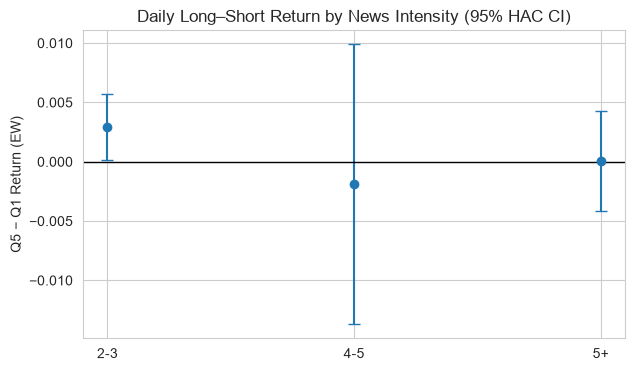

In [12]:
plt.figure(figsize=(7,4))
plt.errorbar(
    news_inference.news_count_bucket, news_inference.estimate,
    yerr=[
        news_inference.estimate - news_inference.hac_ci_low,
        news_inference.hac_ci_high - news_inference.estimate,
    ], fmt="o", capsize=4,
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Daily Long–Short Return by News Intensity (95% HAC CI)")
plt.ylabel("Q5 − Q1 Return (EW)")
plt.show()

Each estimate uses daily within-bucket Q5-minus-Q1 returns with HAC and block-bootstrap uncertainty. The 5+-minus-2–3 paired contrast directly tests whether heavier coverage changes the spread; Holm-adjusted p-values control the three subgroup mean tests.

## 9. Factor-Adjusted Tests
The zero-net-investment Q5-minus-Q1 return is regressed on the daily US market, size, value, and momentum factors. Each signal date $t$ is matched to factors on `return_date_t`, the session when the close-to-close return is realized. Alpha inference uses Newey–West HAC with five lags. Because the spread is zero-cost, the dependent return is not reduced by the risk-free rate.

In [13]:
factor_daily = con.execute("""
SELECT
    date_t, return_date_t, long_short_return_ew,
    mkt_rf, smb, hml, mom, rf
FROM fct_signal_daily_factors
ORDER BY date_t
""").df()
factor_daily["date_t"] = pd.to_datetime(factor_daily["date_t"])

factor_rows = []
factor_samples = {
    "Full sample": factor_daily,
    "In sample": factor_daily[factor_daily.date_t < OOS_START_DATE],
    "Out of sample": factor_daily[factor_daily.date_t >= OOS_START_DATE],
}
for sample_name, sample_frame in factor_samples.items():
    result = factor_alpha(
        sample_frame, "long_short_return_ew",
        ["mkt_rf", "smb", "hml", "mom"], maxlags=HAC_LAGS,
    )
    result["sample"] = sample_name
    factor_rows.append(result)

factor_inference = pd.DataFrame(factor_rows)
factor_inference[[
    "sample", "n_days", "alpha_daily", "alpha_hac_se",
    "alpha_hac_t", "alpha_hac_p", "alpha_ci_low",
    "alpha_ci_high", "r_squared", "beta_mkt_rf",
    "beta_smb", "beta_hml", "beta_mom",
]]

,sample,n_days,alpha_daily,alpha_hac_se,alpha_hac_t,alpha_hac_p,alpha_ci_low,alpha_ci_high,r_squared,beta_mkt_rf,beta_smb,beta_hml,beta_mom
0,Full sample,132,0.002069,0.001255,1.649500,0.099045,-0.000390,0.004528,0.085262,-0.544050,0.143538,0.242108,0.429942
1,In sample,79,0.004720,0.001583,2.980495,0.002878,0.001616,0.007823,0.135423,-1.115715,0.414983,0.145289,0.538732
2,Out of sample,53,-0.001323,0.001479,-0.894503,0.371053,-0.004222,0.001576,0.258445,0.063608,0.082037,0.328494,0.441942


## 10. Chronological Out-of-Sample Test
The holdout begins on 2025-12-15. Signal timing, filters, quintiles, weighting, horizon, and inference settings are frozen across the split; the holdout is not used to tune them. We report each period separately and bootstrap the difference between out-of-sample and in-sample daily means. This is a retrospective pseudo-out-of-sample check, not a prospective live test.

In [14]:
oos_source = factor_daily[["date_t", "long_short_return_ew"]].dropna()
in_sample_returns = oos_source.loc[
    oos_source.date_t < OOS_START_DATE, "long_short_return_ew"
]
out_of_sample_returns = oos_source.loc[
    oos_source.date_t >= OOS_START_DATE, "long_short_return_ew"
]

sample_rows = []
for index, (sample_name, returns) in enumerate({
    "In sample": in_sample_returns,
    "Out of sample": out_of_sample_returns,
}.items()):
    result = hac_mean(returns, maxlags=HAC_LAGS)
    result.update(moving_block_bootstrap_mean(
        returns, BLOCK_LENGTH, BOOTSTRAP_REPETITIONS, RANDOM_SEED + index
    ))
    result["sample"] = sample_name
    result["cumulative_return"] = float((1 + returns).prod() - 1)
    sample_rows.append(result)

oos_inference = pd.DataFrame(sample_rows)
stability_test = two_sample_block_bootstrap_difference(
    out_of_sample_returns, in_sample_returns,
    block_length=BLOCK_LENGTH, repetitions=BOOTSTRAP_REPETITIONS,
    seed=RANDOM_SEED,
)
stability_test["contrast"] = "Out of sample minus in sample"

display(oos_inference[[
    "sample", "n_days", "estimate", "hac_se", "hac_t",
    "hac_p", "hac_ci_low", "hac_ci_high",
    "bootstrap_ci_low", "bootstrap_ci_high", "bootstrap_p",
    "cumulative_return",
]])
display(pd.DataFrame([stability_test]))

,sample,n_days,estimate,hac_se,hac_t,hac_p,hac_ci_low,hac_ci_high,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p,cumulative_return
0,In sample,79,0.004119,0.001526,2.700151,0.006931,0.001129,0.007110,0.001006,0.007162,0.0104,0.363737
1,Out of sample,53,-0.000265,0.001391,-0.190858,0.848637,-0.002992,0.002461,-0.003316,0.002157,0.9140,-0.016458


,difference,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p,contrast
0,-0.004385,-0.008567,-0.00032,0.0368,Out of sample minus in sample


## 11. Data Quality Considerations
To reduce noise in the sentiment signal, the analysis focuses only on stock-days with sufficient news coverage.

Filtering rules applied in the data warehouse:

• `has_sentiment_flag = 1`  
• `news_count > 1`

This requires multiple qualifying ticker-article observations. It does not guarantee independent information because syndicated articles can repeat across sources.

## 12. Conclusion
This study investigates whether financial news sentiment predicts short-term stock returns.

Key findings:

• The 132-day Q5-minus-Q1 mean is positive at about 0.236% per day and is borderline significant with HAC (`p = 0.042`) and the moving-block bootstrap (`p = 0.047`) before costs.

• FF3+momentum-adjusted alpha is about 0.207% per day, but its HAC interval includes zero (`p = 0.099`).

• The 79-day in-sample mean is about 0.412% per day; the 53-day holdout mean is -0.027% and insignificant (`p = 0.849`). The holdout-minus-training difference is about -0.439 percentage points per day and is significant by block bootstrap (`p = 0.037`).

• Neither the low-minus-high liquidity contrast nor the 5+-minus-2–3 news-intensity contrast is significant. The mid-liquidity subgroup survives Holm correction, but the direct contrast does not establish a monotonic liquidity effect.

The full-sample association does not persist out of sample or as statistically significant factor-adjusted alpha, so it is not reliable evidence of tradable alpha. Transaction costs, borrow availability, corporate actions, and a fully point-in-time security-type master remain necessary before implementation.